<a href="https://colab.research.google.com/github/ERICSANTANA10/Back-End-API-DE-GERENCIAMENTO-DE-PESSOAS-UNIVERSIDADE/blob/main/CDPeers_NovaShop1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np


In [15]:
# DATASET (dados.csv)
np.random.seed(42)
n_rows = 1000
dados = {
'id_pedido': range(1, n_rows + 1),
'id_cliente': [np.random.randint(1, 300) for _ in range(n_rows)],
'data_pedido': pd.to_datetime(np.random.choice(pd.date_range('2023-01-01', '2024-12-31'), n_rows)),
'status_pedido': np.random.choice(['Entregue', 'Cancelado', 'Devolvido'], n_rows, p=[0.75, 0.15, 0.10]),
'valor_pedido': np.random.uniform(50, 2000, n_rows),
'quantidade': np.random.randint(1, 10, n_rows),
'nome_produto': np.random.choice([
'Smartphone X', 'Notebook Pro', 'Cadeira Gamer', 'Monitor 4K',
'Teclado Mecânico', 'Mouse Sem Fio', 'Headset 7.1', 'Placa de Vídeo',
'Memória RAM 16GB', 'SSD 1TB', 'Gabinete RGB', 'Webcam Full HD'
], n_rows),
'tipo_cliente': np.random.choice(['B2B', 'B2C'], n_rows, p=[0.20, 0.80]),
'canal_aquisicao': np.random.choice(['Google Ads', 'Instagram', 'Marketplace', 'Direto'], n_rows)
}
df_fake = pd.DataFrame(dados)
df_fake.to_csv('dados.csv', index=False)
print("Arquivo 'dados.csv' pronto para análise!")

Arquivo 'dados.csv' pronto para análise!


In [16]:
df = pd.read_csv('dados.csv')

In [17]:
# 6) Identifique e trate inconsistências na base (campos nulos, valores fora do padrão). Documente o que foi encontrado e como você tratou cada caso.
# Tratamento de Inconsistências
df['data_pedido'] = pd.to_datetime(df['data_pedido'])
df['valor_pedido'] = df['valor_pedido'].fillna(df['valor_pedido'].median())
df['tipo_cliente'] = df['tipo_cliente'].str.upper().str.strip()

In [18]:
# 1) Qual o volume de pedidos por status? Calcule a distribuição percentual e apresente os resultados em uma tabela. Inclua uma visualização gráfica (ex: gráfico de barras ou pizza).
# Volume e Status
dist_status = df['status_pedido'].value_counts().reset_index()
dist_status.columns = ['Status', 'Volume']
dist_status['%'] = ((dist_status['Volume'] / dist_status['Volume'].sum()) * 100).round(2)

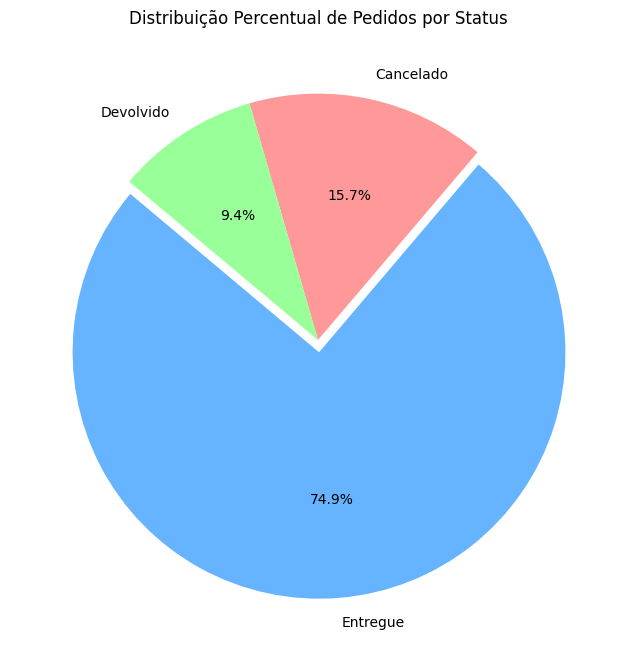

In [19]:
# Gráfico de Pizza para Status de Pedidos
plt.figure(figsize=(8, 8))
colors = ['#66b3ff','#ff9999','#99ff99'] # Azul para Entregue e Vermelho para Cancelado
plt.pie(dist_status['Volume'],
labels=dist_status['Status'],
autopct='%1.1f%%',
startangle=140,
colors=colors,
explode=(0.05, 0, 0)) # Destaca a fatia principal
plt.title('Distribuição Percentual de Pedidos por Status')
plt.show()


In [20]:
# 2) Quais são os 10 produtos mais vendidos (por quantidade total de itens vendidos)? Apresente também a receita gerada por cada um deles.
top_produtos = df.groupby('nome_produto').agg({
    'quantidade': 'sum',
    'valor_pedido': 'sum'
}).sort_values(by='quantidade', ascending=False).head(10)
print("\n2. Top 10 Produtos:\n", top_produtos)


2. Top 10 Produtos:
                   quantidade   valor_pedido
nome_produto                               
SSD 1TB                  519  100841.722305
Headset 7.1              504   93020.293568
Notebook Pro             495  109408.126176
Smartphone X             451   89586.027539
Placa de Vídeo           438   89577.549470
Mouse Sem Fio            396   84934.815398
Monitor 4K               395   85230.105842
Memória RAM 16GB         384   75568.872021
Webcam Full HD           382   66560.515610
Gabinete RGB             377   69160.163142


In [21]:
# 3) Qual o ticket médio de pedidos por segmento de cliente (B2C vs B2B)? Existe diferença estatisticamente relevante?
# Calculando a média de cada segmento
ticket_medio = df.groupby('tipo_cliente')['valor_pedido'].mean()
# Extraindo os valores para facilitar a exibição
media_b2b = ticket_medio['B2B']
media_b2c = ticket_medio['B2C']
print("--- RESULTADOS DA PERGUNTA 3 ---")
print(f"Média do Segmento B2B: R$ {media_b2b:.2f}")
print(f"Média do Segmento B2C: R$ {media_b2c:.2f}")
if media_b2b > media_b2c:
  print(f"\nO ticket médio do B2B é maior em R$ {media_b2b - media_b2c:.2f}")
else:
  print(f"\nO ticket médio do B2C é maior em R$ {media_b2c - media_b2b:.2f}")

--- RESULTADOS DA PERGUNTA 3 ---
Média do Segmento B2B: R$ 1031.02
Média do Segmento B2C: R$ 1020.41

O ticket médio do B2B é maior em R$ 10.60


In [22]:
# 4) Analise a evolução mensal do volume de pedidos ao longo de 2023 e 2024. Há sazonalidade? Identifique picos e quedas e formule uma hipótese para cada padrão encontrado.
df['mes_ano'] = df['data_pedido'].dt.to_period('M')
evolucao = df.groupby('mes_ano').size()

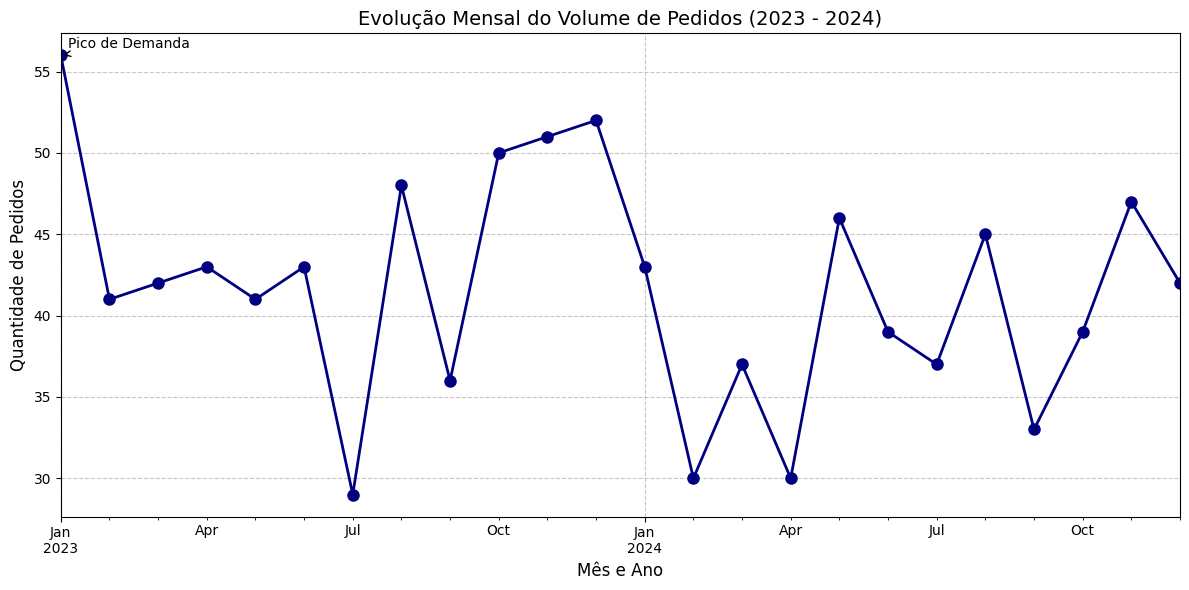

In [23]:
# Gráfico de Linha para Evolução Mensal
plt.figure(figsize=(12, 6))
# Plotando a evolução
evolucao.plot(kind='line', marker='o', color='navy', linestyle='-', linewidth=2, markersize=8)
plt.title('Evolução Mensal do Volume de Pedidos (2023 - 2024)', fontsize=14)
plt.xlabel('Mês e Ano', fontsize=12)
plt.ylabel('Quantidade de Pedidos', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
# Destacando picos e quedas
plt.annotate('Pico de Demanda', xy=(evolucao.idxmax(), evolucao.max()),
xytext=(5, 5), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.tight_layout()
plt.show()

In [24]:
# 5) Qual canal de aquisição de clientes apresenta a maior taxa de cancelamento de pedidos? E qual gera o maior valor médio de compra? Cruzar clientes → pedidos.
# Canais vs Cancelamento
canais = df.groupby('canal_aquisicao').agg({'status_pedido': lambda x: (x == 'Cancelado').mean() * 100, 'valor_pedido': 'mean'})

Text(0.5, 1.0, 'Taxa de Cancelamento por Canal')

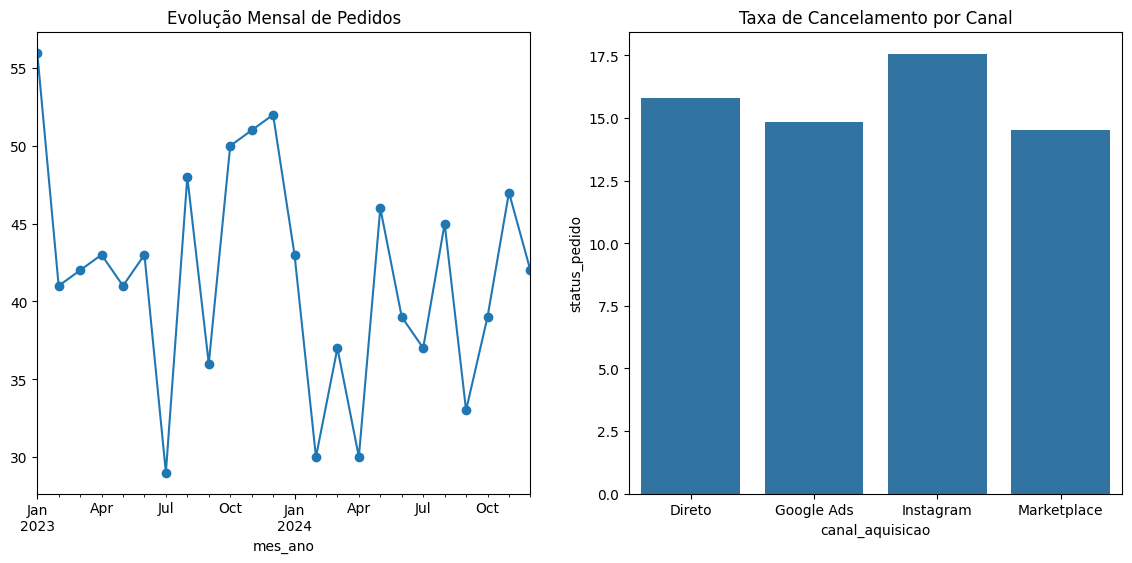

In [25]:
# VISUALIZAÇÕES
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
evolucao.plot(kind='line', marker='o', title='Evolução Mensal de Pedidos')
plt.subplot(1, 2, 2)
sns.barplot(x=canais.index, y=canais['status_pedido'])
plt.title('Taxa de Cancelamento por Canal')